# Прототип: интерпретация ионограмм ВЗ с онтологическим контуром

**Задача ноутбука** — пройти путь «от простого к сложному» и получить работающий прототип:

1. посмотреть **глазами на сырьё** (байты RSF → матрица «частота × высота»);
2. посмотреть **глазами на цель** (SAO — разметка ARTIST: следы + характеристики);
3. **формально поставить задачу** обучения (модельное представление ARTIST);
4. проверить **онтологию** (`03-ionograms-ontology/research/onto`) на инвариантность НЗ → ВЗ и
   расширить её формами вертикального зондирования;
5. построить **логическую голову** (2 варианта релаксации: hinge-штраф и softplus ≈ −log σ)
   и **SHACL-гейт** на инференсе;
6. построить **U-Net в двух вариантах** (для абляции по координатным каналам);
7. провести **smoke-обучение на CPU** (4 рана: baseline, +hinge, +lognorm, +coords)
   и сравнить: IoU, foF2-ридаут vs ARTIST, доля SHACL-нарушений.

Контекст и источники: `data/format_description.md` (Части I–II), тезисы
`03-ionograms-ontology/` (онтология, формы S1–S6, методика CQ). Данные — открытый архив NOAA
(`data/download_corpus.sh`; ячейки подбирают всё, что успело докачаться) + образцы из `data/`.

> Прототип, а не результат: маленькая сеть, маленькая выборка, 4 минуты обучения.
> Цель — отработать постановку и конвейер, а не получить метрики.

In [1]:
import sys, glob, io, time, json, warnings
warnings.filterwarnings("ignore")
ROOT = "/Users/andreykhalov/HULK/PHD/conferences/2026/vitebsk/research_ionogramms"
sys.path.insert(0, ROOT); sys.path.insert(0, f"{ROOT}/pynasonde_git")

import numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as Fn
import matplotlib.pyplot as plt
from modules import digi_formats as dfm

torch.manual_seed(0); np.random.seed(0)
plt.rcParams.update({"font.size": 9, "figure.dpi": 100})
DATA = f"{ROOT}/data"; CORPUS = f"{DATA}/corpus"
ONTO = f"{ROOT}/03-ionograms-ontology/research/onto"
print("torch", torch.__version__, "| файлов в корпусе:",
      len(glob.glob(f"{CORPUS}/*/*/*/ionogram/*.*")))

torch 2.10.0 | файлов в корпусе: 1302


## 1. Сырьё глазами: что лежит в RSF-файле

RSF — бинарные блоки по 4096 байт: 60-байтный заголовок (PREFACE, packed BCD) + частотные
группы (6-байтная прелюдия + 2 байта на бин дальности: 5 бит амплитуды ×3 дБ, 3 бита доплера,
5 бит фазы, 3 бита азимута). Смотрим на первые байты и разбираем их руками, затем — парсером.

In [2]:
raw_file = sorted(glob.glob(f"{CORPUS}/JI91J/2022/002/ionogram/*.RSF"))[0]
raw = open(raw_file, "rb").read()
print(raw_file.split('/')[-1], f"— {len(raw)} байт = {len(raw)//4096} блоков по 4096\n")
print("первые 64 байта (hex):")
for off in range(0, 64, 16):
    print(f"  {off:04x}: " + " ".join(f"{b:02x}" for b in raw[off:off+16]))
bcd = lambda b: 10*(b >> 4) + (b & 15)
print("\nразбор вручную: record_type =", raw[0], "(7 = первый блок RSF), header_len =", raw[1],
      "\n  дата = 20%02d-%02d-%02d %02d:%02d:%02d UT" % tuple(bcd(raw[i]) for i in (3,6,7,8,9,10)),
      "\n  частоты: %d.%02d–%d.%02d МГц, шаг %d кГц" % (bcd(raw[19]), bcd(raw[20]), bcd(raw[24]), bcd(raw[25]), bcd(raw[22])*100+bcd(raw[23])),
      "\n  дальность: старт %d км, шаг код %d, высот %d" % (bcd(raw[35])*100+bcd(raw[36]), bcd(raw[37]), bcd(raw[38])*100+bcd(raw[39])))
# то же самое парсером
pf, df_raw = dfm.read_ionogram(raw_file)
print("\nparser:", pf.date, f"{pf.f_start_hz/1e6:g}–{pf.f_stop_hz/1e6:g} МГц, "
      f"{pf.n_heights} высот × {pf.range_inc_km} км, формат {pf.format_name}")
df_raw.head(3)

JI91J_2022002000000.RSF — 114688 байт = 28 блоков по 4096

первые 64 байта (hex):
  0000: 07 3c fe 22 00 02 01 02 00 00 00 30 31 32 30 31
  0010: 32 06 02 01 00 00 01 00 12 00 00 00 00 01 01 07
  0020: 03 01 00 00 80 05 02 56 00 00 00 02 00 04 00 00
  0030: 00 14 00 00 3b 06 00 90 06 40 00 08 33 01 00 4a

разбор вручную: record_type = 7 (7 = первый блок RSF), header_len = 60 
  дата = 2022-01-02 00:00:00 UT 
  частоты: 1.00–12.00 МГц, шаг 100 кГц 
  дальность: старт 80 км, шаг код 5, высот 256

parser: 2022-01-02 00:00:00 1–12 МГц, 256 высот × 5.0 км, формат RSF


,height_km,amp_db,doppler,phase_deg,azimuth_deg,block,pol,freq_hz,offset_hz,offset_flag,add_gain_db,seconds,mpa_db,freq_mhz
0,80.0,78.0,0,45.00,120,0,O,1000000.0,20000.0,,30,1,78,1.0
1,85.0,81.0,4,191.25,120,0,O,1000000.0,20000.0,,30,1,78,1.0
2,90.0,72.0,6,112.50,360,0,O,1000000.0,20000.0,,30,1,78,1.0


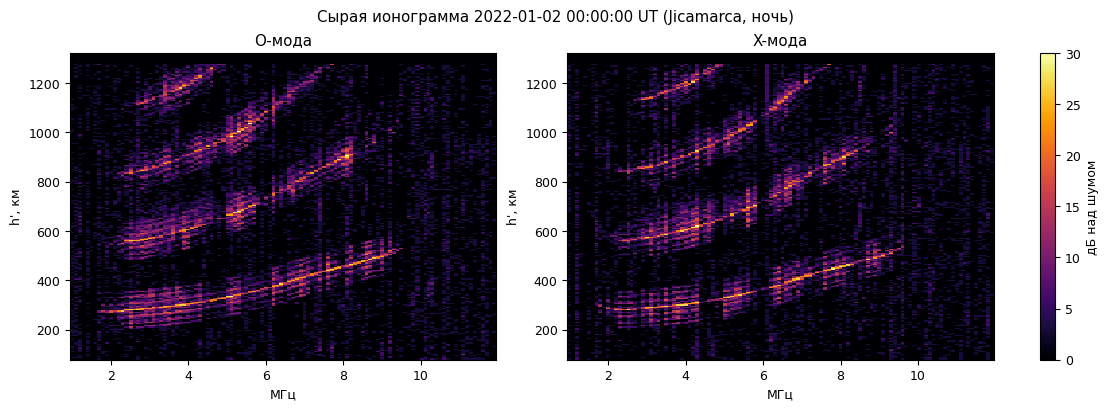

In [3]:
# матрица «частота × высота»: два канала — O- и X-поляризация, амплитуда минус уровень шума (MPA)
def native_matrix(df, pol):
    s = df[df.pol == pol]
    p = s.pivot_table(index="height_km", columns="freq_mhz", values="amp_db", aggfunc="first")
    m = s.pivot_table(index="height_km", columns="freq_mhz", values="mpa_db", aggfunc="first")
    return p.columns.values, p.index.values, np.clip(p.values - m.values, 0, None)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for ax, pol in zip(axes, ["O", "X"]):
    f, h, a = native_matrix(df_raw, pol)
    pc = ax.pcolormesh(f, h, a, cmap="inferno", vmin=0, vmax=30, shading="nearest")
    ax.set_title(f"{pol}-мода"); ax.set_xlabel("МГц"); ax.set_ylabel("h', км")
fig.colorbar(pc, ax=axes, label="дБ над шумом"); fig.suptitle(f"Сырая ионограмма {pf.date} UT (Jicamarca, ночь)")
plt.show()
# ночной след F2 + кратники 2F/3F; всё выше ~600 км — копии основного следа, их надо НЕ путать со слоями

## 2. Цель глазами: SAO — разметка ARTIST

Рядом с каждым RSF лежит SAO (текст, фикс. форматы): ~40 характеристик, **следы** —
полилинии *h′(f)* по узлам сетки прибора (не сплайн! одна высота на частоту), профиль Nₑ(h).
Это **автоматическая** разметка (в группе edit-flags нет значений 4/5 «правил человек»),
т.е. слабый учитель с самооценкой (C-level).

In [4]:
sao_file = raw_file.replace("/ionogram/", "/scaled/").replace(".RSF", ".SAO")
print("".join(open(sao_file).readlines()[:6]))          # так выглядит сырой SAO: индекс групп + данные
sao = dfm.read_sao(sao_file)
print("характеристики:", sao["scaled"].dropna().to_dict())
print("след F2 (O):", len(sao.get("F2o_freq", [])), "точек")

  5  1 77 43 20  8 70  0 70 70 70  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 10  0  7 73
120  2  0  0  0  0  0  0  0  0 95 95 95  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  4
   .800  2.000-12.000283.200 -1.000
DPS-4 204/JI91J, ARTIST 0702, NH 4.21 |                                                                                 
FF202200201020000000120126201000010012000000001107301000080502560000020140000
   9.1009999.000   2.709  24.655   2.2009999.000   2.2009999.0009999.000   9.500 268.0009999.0009999.0009999.000 110.000

характеристики: {'foF2': 9.1, 'M3000F2': 2.709, 'MUF3000F2': 24.655, 'fmin': 2.2, 'fminF': 2.2, 'fxI': 9.5, 'hF': 268.0, 'zmE': 110.0, 'yE': 20.0, 'DownF': 0.0, 'D': 3000.0, 'fMUF': 9.1, 'h_fMUF': 495.0, 'delta_foF2': 0.0, 'foEp': 0.652, 'f_hF': 2.2, 'hmF2': 372.7, 'zhalfNm': 307.446, 'foF2p': 7.446, 'yF2': 95.77, 'TEC': 20.593, 'scaleF2': 45.962, 'B0': 112.1, 'B1': 1.17, 'D1': 0.0}
след F2 (O): 70

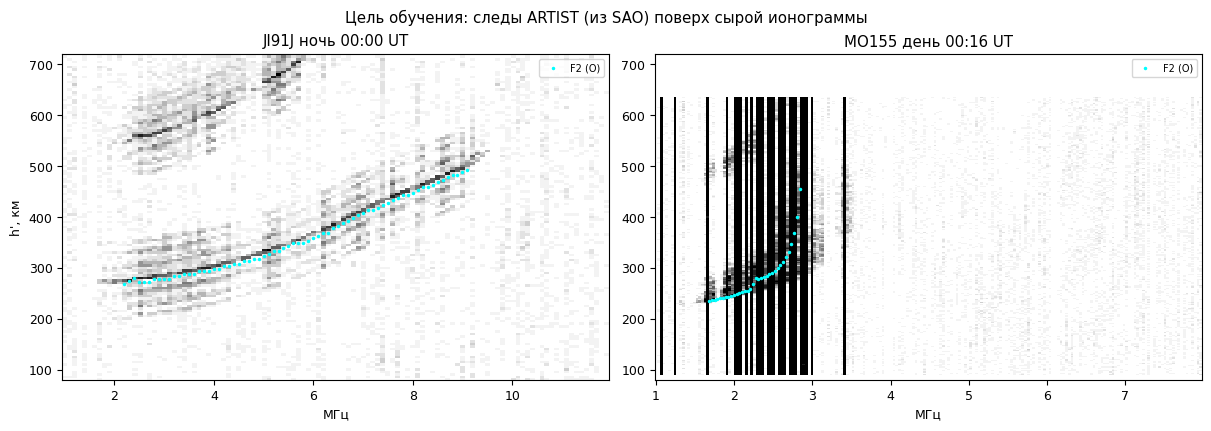

In [5]:
# следы ARTIST поверх матрицы + дневная ионограмма MO155 для контраста (там есть E и F1)
day_file = sorted(glob.glob(f"{CORPUS}/MO155/2019/*/ionogram/*1200*.RSF") or
                  glob.glob(f"{CORPUS}/MO155/2019/*/ionogram/*.RSF"))
TRACES = [("F2o", "F2 (O)", "cyan"), ("F1o", "F1 (O)", "lime"), ("Eo", "E (O)", "yellow"), ("Es", "Es", "magenta")]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
for ax, (rf, ttl) in zip(axes, [(raw_file, "JI91J ночь"), (day_file[len(day_file)//2], "MO155 день")]):
    pfi, dfi = dfm.read_ionogram(rf); si = dfm.read_sao(rf.replace("/ionogram/", "/scaled/").rsplit(".",1)[0] + ".SAO")
    f, h, a = native_matrix(dfi, "O")
    ax.pcolormesh(f, h, a, cmap="Greys", vmin=0, vmax=30, shading="nearest")
    for key, lab, c in TRACES:
        if len(si.get(f"{key}_freq", [])): ax.plot(si[f"{key}_freq"], si[f"{key}_vh"], ".", ms=3, color=c, label=lab)
    ax.set_ylim(80, 720); ax.set_title(f"{ttl} {pfi.date:%H:%M} UT"); ax.set_xlabel("МГц"); ax.legend(fontsize=7)
axes[0].set_ylabel("h', км"); fig.suptitle("Цель обучения: следы ARTIST (из SAO) поверх сырой ионограммы")
plt.show()

## 3. Постановка задачи обучения (модельное представление ARTIST)

**Вход** $x \in \mathbb{R}^{2\times H\times F}$ — матрица «частота × высота», каналы O/X,
амплитуда над шумом, приведённая к канонической сетке (здесь $128\times128$, 1–15 МГц × 80–720 км).

**Выход** $y$ — послойно (уровни L1–L4 из `03-ionograms-ontology`):
- **L2 (главное здесь):** маска классов следов $y[h, f] \in \{BG, F2, F1, E, Es\}$ —
  растеризация SAO-полилиний (±1 бин по высоте). O-следы; X-следов ARTIST в наших SAO не пишет;
- **L3:** мода следа = кортеж признаков (кратность, слой, компонента) — словарь онтологии;
- **L4:** характеристики (foF2, h′F, …) — **не отдельной головой**, а дифференцируемым
  *ридаутом* из масок (правило тезисов: модель — не измеритель).

**Учитель** — ARTIST (слабый: 60–80 % правильной идентификации по обзору Щирого-2007), поэтому
постановка с ограничением: $\Phi(x) \models \mathcal{O}$ — физическая допустимость проверяется
независимо от учителя. Реализация трёхслойная:

| слой | где живёт | что делает |
|---|---|---|
| логическая голова | в лоссе | $L = L_{CE} + \lambda\, L_{logic}$, $L_{logic}$ — релаксация пропозиций |
| SHACL-гейт | на инференсе | предсказание → RDF-сцена → owlrl → pyshacl → нарушения |
| фильтр учителя | в данных | (в прототипе не используем; для полного корпуса — отсев SAO, не прошедших SHACL) |

**Эксперимент:** одна архитектура, раны `baseline` / `+hinge` / `+lognorm` (два варианта
релаксации) + абляция `+coords` (координатные каналы: физика не транс-инвариантна).
Метрики: IoU по классам, RMSE ридаута foF2 против ARTIST, доля SHACL-нарушений.

## 4. Онтология: инвариантна ли она к переходу НЗ → ВЗ

Онтология из тезисов делалась для **наклонного** зондирования. Проверяем перенос на ВЗ на
сцене из **реального** SAO (JI91J 00:00 UT). Мост между мирами: групповая задержка ↔
действующая высота, τ [мс] = 2h′/c. Ожидания:

| форма НЗ | смысл | на ВЗ |
|---|---|---|
| S1 (МНЧ убывает с кратностью) | закон секанса | вырождается корректно: у кратников ВЗ та же асимптота foF2, равенство проходит допуск |
| S2 (задержка растёт с кратностью) | геометрия | **переносится как есть** (h′ₙ ≈ n·h′₁) |
| S3 (парность лучей), S6 (задержка 1F2п) | педерсеновский луч | вакуумно истинны: в ВЗ верхнего луча нет |
| S4 (задержка растёт с высотой слоя) | E ниже F | **переносится как есть** (h′E < h′F1 < h′F2) |
| S5 (два следа ≠ одна мода) | уникальность | переносится |
| — | кратник ≈ n × основной | **новая V3** (ВЗ-расширение) |
| — | fx − fo ≈ f_H/2 | **новая V4** (ВЗ-расширение) |

ВЗ-расширение пишем декларативно (это и есть заявленное свойство подхода: новое правило =
новый TTL, не правка кода) в `modules/onto/iono-shapes-vs.ttl`.

In [6]:
import rdflib, owlrl, pyshacl
from rdflib import Graph, Namespace, Literal, RDF, URIRef
from rdflib.namespace import XSD
IONO = Namespace("http://scilibai.ru/onto/iono#"); C_KM_MS = 299.792458

core = Graph().parse(f"{ONTO}/iono-core.ttl")
shapes_oi = Graph().parse(f"{ONTO}/iono-shapes.ttl"); shapes_oi.parse(f"{ONTO}/iono-shapes-ext.ttl")
print(f"ядро: {len(core)} триплетов; классов: {len(set(core.subjects(RDF.type, URIRef('http://www.w3.org/2002/07/owl#Class'))))}")

VS_EXT = """@prefix iono: <http://scilibai.ru/onto/iono#> .
@prefix sh:   <http://www.w3.org/ns/shacl#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd:  <http://www.w3.org/2001/XMLSchema#> .
@prefix owl:  <http://www.w3.org/2002/07/owl#> .

iono:hasGyroFrequency a owl:DatatypeProperty , owl:FunctionalProperty ;
    rdfs:domain iono:Ionogram ; rdfs:range xsd:decimal ;
    rdfs:label "гирочастота электронов на станции, МГц"@ru .

iono:IonogramVSShape a sh:NodeShape ;
    sh:targetClass iono:Ionogram ;
    rdfs:label "Ограничения вертикального зондирования (V3, V4)"@ru ;
    sh:sparql [ a sh:SPARQLConstraint ;
        sh:message "V3: задержка кратника {?m2} не кратна задержке основного следа {?m1}"@ru ;
        sh:severity sh:Violation ; sh:prefixes iono: ;
        sh:select \"\"\"
            SELECT $this ?m1 ?m2 WHERE {
              ?t1 iono:isTraceIn $this ; iono:denotes ?m1 .
              ?t2 iono:isTraceIn $this ; iono:denotes ?m2 .
              ?m1 iono:hasHopCount 1 ; iono:hasMinDelayValue ?d1 ;
                  iono:reflectsFromLayer ?L ; iono:hasMagnetoionicComponent ?c .
              ?m2 iono:hasHopCount ?n2 ; iono:hasMinDelayValue ?d2 ;
                  iono:reflectsFromLayer ?L ; iono:hasMagnetoionicComponent ?c .
              FILTER (?n2 > 1)
              FILTER (?d2 < ?d1 * ?n2 * 0.88 || ?d2 > ?d1 * ?n2 * 1.12)
            }
        \"\"\" ] ;
    sh:sparql [ a sh:SPARQLConstraint ;
        sh:message "V4: расщепление O/X пары {?mo}/{?mx} не согласуется с гирочастотой"@ru ;
        sh:severity sh:Violation ; sh:prefixes iono: ;
        sh:select \"\"\"
            SELECT $this ?mo ?mx WHERE {
              $this iono:hasGyroFrequency ?fh .
              ?t1 iono:isTraceIn $this ; iono:denotes ?mo .
              ?t2 iono:isTraceIn $this ; iono:denotes ?mx .
              ?mo iono:hasMagnetoionicComponent iono:ordinary ;
                  iono:hasHopCount ?n ; iono:reflectsFromLayer ?L ; iono:hasMOFValue ?fo .
              ?mx iono:hasMagnetoionicComponent iono:extraordinary ;
                  iono:hasHopCount ?n ; iono:reflectsFromLayer ?L ; iono:hasMOFValue ?fx .
              FILTER ( ?fx - ?fo > ?fh/2 + 0.3 || ?fx - ?fo < ?fh/2 - 0.3 )
            }
        \"\"\" ] .

iono: sh:declare [ sh:prefix "iono" ; sh:namespace "http://scilibai.ru/onto/iono#"^^xsd:anyURI ] .
"""
import os; os.makedirs(f"{ROOT}/modules/onto", exist_ok=True)
open(f"{ROOT}/modules/onto/iono-shapes-vs.ttl", "w").write(VS_EXT)
shapes = shapes_oi + Graph().parse(data=VS_EXT, format="turtle")
print("формы: S1–S6 (наклонные) + V3, V4 (ВЗ) — записано в modules/onto/iono-shapes-vs.ttl")

ядро: 475 триплетов; классов: 53
формы: S1–S6 (наклонные) + V3, V4 (ВЗ) — записано в modules/onto/iono-shapes-vs.ttl


In [7]:
# ВЗ-сцена как граф. ВНИМАНИЕ: литералы пишем СТРОКАМИ — numpy.float64 в xsd:decimal
# ломает арифметику SPARQL в rdflib (ошибка в ветке «||» превращается в истину).
def vs_scene(name, modes, gyro_mhz):
    g = Graph(); g.bind("iono", IONO)
    ion = IONO["ion_" + name]; g.add((ion, RDF.type, IONO.Ionogram))
    g.add((ion, IONO.hasGyroFrequency, Literal(f"{float(gyro_mhz):.3f}", datatype=XSD.decimal)))
    for i, m in enumerate(modes, 1):
        tr, mo = IONO[f"{name}_tr{i}"], IONO[f"{name}_m{i}"]
        for t in [(tr, RDF.type, IONO.IonogramTrace), (tr, IONO.isTraceIn, ion), (tr, IONO.denotes, mo),
                  (mo, RDF.type, IONO.PropagationMode),
                  (mo, IONO.hasModeLabel, Literal(m["label"])),
                  (mo, IONO.hasHopCount, Literal(int(m["hop"]), datatype=XSD.integer)),
                  (mo, IONO.hasRayType, IONO.lowerRay),                       # в ВЗ верхнего луча нет
                  (mo, IONO.hasMagnetoionicComponent, IONO[m["comp"]]),
                  (mo, IONO.reflectsFromLayer, IONO["Layer_" + m["layer"]]),
                  (mo, IONO.hasMOFValue, Literal(f"{float(m['mof']):.3f}", datatype=XSD.decimal)),
                  (mo, IONO.hasMinDelayValue, Literal(f"{2*float(m['hkm'])/C_KM_MS:.4f}", datatype=XSD.decimal))]:
            g.add(t)
    return g

def check_scene(name, modes, gyro=1.13, verbose=True):
    data = vs_scene(name, modes, gyro) + core
    owlrl.DeductiveClosure(owlrl.OWLRL_Semantics).expand(data)
    inferred = sorted({(str(s).split("#")[-1], str(o).split("#")[-1])
                       for s, _, o in data.triples((None, RDF.type, None))
                       if str(o).split("#")[-1].startswith("Mode_")})
    ok, rg, _ = pyshacl.validate(data_graph=data, shacl_graph=shapes, inference="none", advanced=True)
    msgs = sorted({str(m).split("#")[0][:4] + ": " + str(m)[:80] for m in
                   rg.objects(None, URIRef("http://www.w3.org/ns/shacl#resultMessage"))})
    if verbose:
        print(f"[{name}] допустима: {ok}; ризонер вывел:", {k: v for k, v in inferred})
        for m in sorted({str(x)[:100] for x in rg.objects(None, URIRef('http://www.w3.org/ns/shacl#resultMessage'))}): print("   ✗", m)
    return ok

# сцена из реального SAO JI91J 00:00 UT: 1F2(O), 1F2(X), кратники 2F2, 3F2
sc = dfm.read_sao(f"{DATA}/RSF-samples-w-img-n-sao-n-dft/scaled/JI91J_2022001000000.SAO")["scaled"]
foF2, fxI, hF = float(sc["foF2"]), float(sc["fxI"]), float(sc["hF"])
good = [dict(label="1F2",  hop=1, layer="F2", comp="ordinary",      mof=foF2, hkm=hF),
        dict(label="1F2x", hop=1, layer="F2", comp="extraordinary", mof=fxI,  hkm=hF+5),
        dict(label="2F2",  hop=2, layer="F2", comp="ordinary",      mof=foF2, hkm=2*hF+10),
        dict(label="3F2",  hop=3, layer="F2", comp="ordinary",      mof=foF2, hkm=3*hF+20)]
bad_swap = [dict(good[0], hkm=2*hF+10), good[1], dict(good[2], hkm=hF), good[3]]   # 1F2 ↔ 2F2
bad_x    = [good[0], dict(good[1], mof=foF2+2.5), good[2], good[3]]                # X сдвинут на 2.5 МГц
print("=== A: правильная разметка (из SAO)"); check_scene("A_vs", good)
print("\n=== B: обозначения 1F2 и 2F2 переставлены (визуально та же ионограмма!)"); check_scene("B_vs", bad_swap)
print("\n=== C: O/X-пара с неверным расщеплением"); check_scene("C_vs", bad_x)

=== A: правильная разметка (из SAO)


[A_vs] допустима: True; ризонер вывел: {'A_vs_m1': 'Mode_1F2', 'A_vs_m2': 'Mode_1F2', 'A_vs_m3': 'Mode_2F2', 'A_vs_m4': 'Mode_3F2'}

=== B: обозначения 1F2 и 2F2 переставлены (визуально та же ионограмма!)


[B_vs] допустима: False; ризонер вывел: {'B_vs_m1': 'Mode_1F2', 'B_vs_m2': 'Mode_1F2', 'B_vs_m3': 'Mode_2F2', 'B_vs_m4': 'Mode_3F2'}
   ✗ S2: нарушена монотонность задержки по кратности — задержка моды http://scilibai.ru/onto/iono#B_vs_m3
   ✗ V3: задержка кратника http://scilibai.ru/onto/iono#B_vs_m3 не кратна задержке основного следа http:/
   ✗ V3: задержка кратника http://scilibai.ru/onto/iono#B_vs_m4 не кратна задержке основного следа http:/

=== C: O/X-пара с неверным расщеплением


[C_vs] допустима: False; ризонер вывел: {'C_vs_m1': 'Mode_1F2', 'C_vs_m2': 'Mode_1F2', 'C_vs_m3': 'Mode_2F2', 'C_vs_m4': 'Mode_3F2'}
   ✗ V4: расщепление O/X пары http://scilibai.ru/onto/iono#C_vs_m1/http://scilibai.ru/onto/iono#C_vs_m2 н


False

**Итог проверки инвариантности.** Правильная ВЗ-разметка проходит все формы НЗ; ризонер
выводит классы мод (`Mode_1F2`, `Mode_2F2`, `Mode_3F2`) из кортежей признаков — метка нигде
не задавалась. Перестановку 1F2↔2F2 (по картинке неразличимую) ловит «наклонная» S2 и новая V3;
сбитое O/X-расщепление — только новая V4. То есть **ядро онтологии — инвариант** (мода =
кортеж признаков; след ≠ мода), часть форм переносится дословно (S2, S4, S5), часть вырождается
корректно (S1) или вакуумно (S3, S6 — нет педерсеновского луча), и ВЗ добавляет свои (V3, V4).

## 5. Датасет: каноническая сетка + маски из SAO

Сетки станций разные (JI91J 100 кГц × 5 км, MO155 50 кГц × 5 км, RO041 50 кГц × 2.5 км) —
приводим к канонической 128×128 (1–15 МГц × 80–720 км, ближайший сосед). Маска классов:
растеризация SAO-полилиний ±1 бин по высоте. Сплит — **по времени** (хронологически внутри
каждой станции), как в NOIRE-Net: соседние 15-минутки сильно скоррелированы.

In [8]:
NF = NH = 128; F_MIN, F_MAX, H_MIN, H_MAX = 1.0, 15.0, 80.0, 720.0
CLASSES = ["BG", "F2", "F1", "E", "Es"]; TR_KEYS = {"F2": "F2o", "F1": "F1o", "E": "Eo", "Es": "Es"}
f_axis = np.linspace(F_MIN, F_MAX, NF); h_axis = np.linspace(H_MIN, H_MAX, NH)

def canon_matrix(df):
    out = np.zeros((2, NH, NF), np.float32)
    for ci, pol in enumerate(["O", "X"]):
        s = df[df.pol == pol]
        if not len(s): continue
        fs = np.sort(s.freq_mhz.unique()); hs = np.sort(s.height_km.unique())
        m = np.zeros((len(hs), len(fs)), np.float32)
        m[np.searchsorted(hs, s.height_km.values), np.searchsorted(fs, s.freq_mhz.values)] = \
            np.clip(s.amp_db.values - s.mpa_db.values, 0, 30) / 30
        fj = np.clip(np.searchsorted(fs, f_axis), 0, len(fs)-1); hj = np.clip(np.searchsorted(hs, h_axis), 0, len(hs)-1)
        okf = (f_axis >= fs[0]) & (f_axis <= fs[-1]); okh = (h_axis >= hs[0]) & (h_axis <= hs[-1])
        out[ci][np.ix_(okh, okf)] = m[np.ix_(hj[okh], fj[okf])]
    return out

def masks_from_sao(sao):
    y = np.zeros((NH, NF), np.int64)
    for cls, key in TR_KEYS.items():
        fq, vh = sao.get(f"{key}_freq"), sao.get(f"{key}_vh")
        if fq is None or not len(fq): continue
        ci = CLASSES.index(cls)
        for f0, h0 in zip(np.asarray(fq, float), np.asarray(vh, float)):
            if not (F_MIN <= f0 <= F_MAX and H_MIN <= h0 <= H_MAX): continue
            jf = int(round((f0-F_MIN)/(F_MAX-F_MIN)*(NF-1))); jh = int(round((h0-H_MIN)/(H_MAX-H_MIN)*(NH-1)))
            y[max(jh-1, 0):jh+2, jf] = ci
    return y

pats = [f"{CORPUS}/*/*/*/ionogram/*.RSF", f"{DATA}/RSF-samples-w-img-n-sao-n-dft/ionogram/*.RSF",
        f"{DATA}/SBF-samples-w-img-n-sao/ionogram/*.SBF"]
files = sorted({f for p in pats for f in glob.glob(p)})
X, Y, meta = [], [], []
t0 = time.time()
for f in files:
    sao_f = f.replace("/ionogram/", "/scaled/").rsplit(".", 1)[0] + ".SAO"
    try:
        _, dfi = dfm.read_ionogram(f); si = dfm.read_sao(sao_f)
    except Exception:
        continue
    X.append(canon_matrix(dfi)); Y.append(masks_from_sao(si))
    meta.append(dict(stem=f.split("/")[-1], station=f.split("/")[-1][:5],
                     foF2=float(si["scaled"].get("foF2", np.nan)), hF=float(si["scaled"].get("hF", np.nan))))
X, Y = np.stack(X), np.stack(Y); meta = pd.DataFrame(meta)
# хронологический сплит внутри станции: последние 25% каждой станции — валидация
val_mask = np.zeros(len(meta), bool)
for st, idx in meta.groupby("station").groups.items():
    idx = sorted(idx); val_mask[idx[int(len(idx)*0.75):]] = True
tr_i, va_i = np.where(~val_mask)[0], np.where(val_mask)[0]
print(f"{len(X)} ионограмм за {time.time()-t0:.0f} с; train {len(tr_i)} / val {len(va_i)}")
print(meta.station.value_counts().to_dict())
print("пиксели классов:", dict(zip(CLASSES, np.bincount(Y.ravel(), minlength=5))))

1485 ионограмм за 498 с; train 1112 / val 373
{'MO155': 1205, 'JI91J': 191, 'RO041': 89}
пиксели классов: {'BG': 24250990, 'F2': 73426, 'F1': 1155, 'E': 2110, 'Es': 2559}


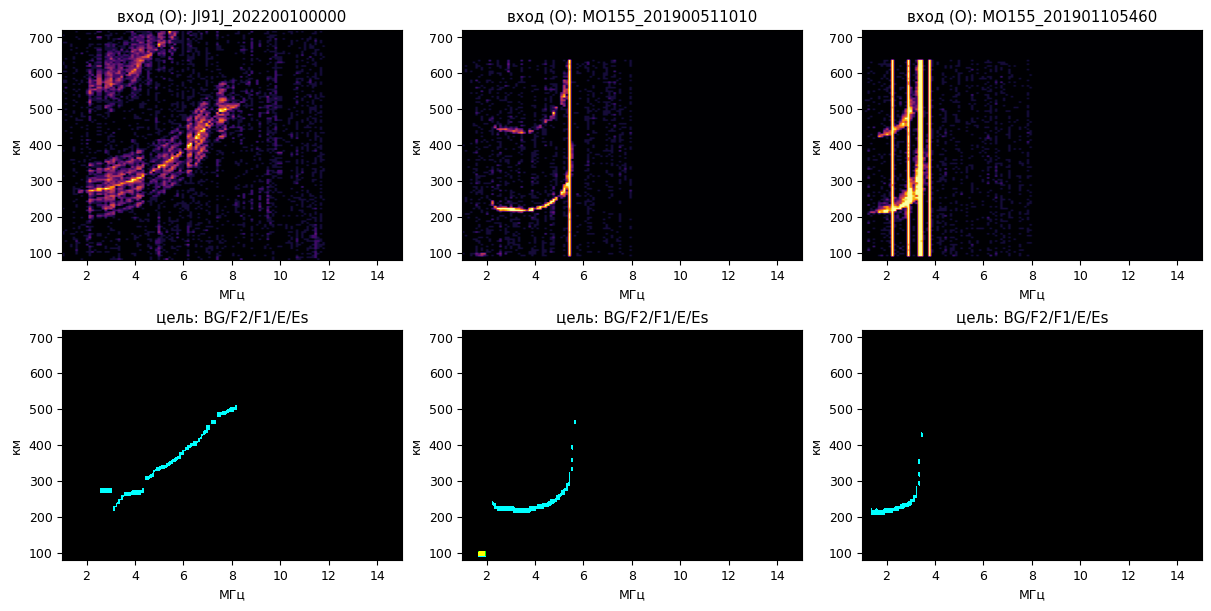

In [9]:
# смотрим глазами пары «вход | цель»
show = [tr_i[0], tr_i[len(tr_i)//2], tr_i[-1]]
fig, axes = plt.subplots(2, 3, figsize=(12, 6), constrained_layout=True)
from matplotlib.colors import ListedColormap
cm_y = ListedColormap(["black", "cyan", "lime", "yellow", "magenta"])
for j, i in enumerate(show):
    axes[0, j].imshow(X[i, 0], origin="lower", cmap="inferno", aspect="auto",
                      extent=[F_MIN, F_MAX, H_MIN, H_MAX], vmin=0, vmax=1)
    axes[0, j].set_title(f"вход (O): {meta.stem[i][:18]}")
    axes[1, j].imshow(Y[i], origin="lower", cmap=cm_y, aspect="auto", extent=[F_MIN, F_MAX, H_MIN, H_MAX], vmin=0, vmax=4)
    axes[1, j].set_title("цель: BG/F2/F1/E/Es")
for ax in axes.ravel(): ax.set_xlabel("МГц"); ax.set_ylabel("км")
plt.show()

## 6. Модель: U-Net (паттерн) в двух вариантах

U-Net здесь — **паттерн** (энкодер-декодер со skip): ~120 тыс. параметров, заведомо по силам
CPU. Два варианта для абляции:
- **v1** — чистые свёртки (транс-инвариантны, «не знают», где 100 км, а где 400);
- **v2 (+coords)** — добавлены каналы абсолютных координат (f, h): физика ионограммы
  НЕ инвариантна к сдвигу (E живёт у 100 км, кратник — на 2h′).

Одно ограничение вшито **архитектурно**: softmax по классам в каждом пикселе; «≤1 высота на
частоту» обеспечивается ридаутом (soft-argmax по столбцу), а не декодером — честная точка
роста для v3 (DETR-слоты мод).

In [10]:
class Block(nn.Module):
    def __init__(s, ci, co):
        super().__init__()
        s.n = nn.Sequential(nn.Conv2d(ci, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(),
                            nn.Conv2d(co, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU())
    def forward(s, x): return s.n(x)

class UNet(nn.Module):
    def __init__(s, cin=2, base=16, ncls=5, coords=False):
        super().__init__(); s.coords = coords
        cin += 2 if coords else 0
        s.d1, s.d2, s.d3 = Block(cin, base), Block(base, base*2), Block(base*2, base*4)
        s.u2 = nn.ConvTranspose2d(base*4, base*2, 2, 2); s.b2 = Block(base*4, base*2)
        s.u1 = nn.ConvTranspose2d(base*2, base, 2, 2);   s.b1 = Block(base*2, base)
        s.head = nn.Conv2d(base, ncls, 1); s.pool = nn.MaxPool2d(2)
    def forward(s, x):
        if s.coords:
            B, _, H, W = x.shape
            hh = torch.linspace(0, 1, H, device=x.device).view(1, 1, H, 1).expand(B, 1, H, W)
            ww = torch.linspace(0, 1, W, device=x.device).view(1, 1, 1, W).expand(B, 1, H, W)
            x = torch.cat([x, hh, ww], 1)
        c1 = s.d1(x); c2 = s.d2(s.pool(c1)); c3 = s.d3(s.pool(c2))
        y = s.b2(torch.cat([s.u2(c3), c2], 1)); y = s.b1(torch.cat([s.u1(y), c1], 1))
        return s.head(y)

print("параметров v1:", sum(p.numel() for p in UNet().parameters()),
      "| v2:", sum(p.numel() for p in UNet(coords=True).parameters()))

параметров v1: 117605 | v2: 117893


## 7. Логическая голова: пропозиции онтологии → дифференцируемый лосс

Схема «заземление → атомы → t-нормы» (Logic Tensor Networks): из выходов сети строим
непрерывные **ридауты**, из них — степени истинности пропозиций, нарушение штрафуем.

Пропозиции (каждая привязана к форме онтологии):

| | пропозиция | форма | ридаут |
|---|---|---|---|
| **P1** | слои упорядочены по высоте: $\bar h_E + 20 < \bar h_{F2}$, $\bar h_{F1} + 10 < \bar h_{F2}$, $\bar h_E + 10 < \bar h_{F1}$ | S4 / V2 | $\bar h_c$ — средняя (по массе класса) высота |
| **P2** | след непрерывен: $|h_c(f_{j+1}) - h_c(f_j)| \le 60$ км | РД §7.3 (связность следа) | $h_c(f)$ — soft-argmax по столбцу |
| **P3** | след F2 — первая кратность: $h_{F2}(f) \le 1.8\cdot\min_f h_{F2}$ | V3 | масса класса выше порога штрафуется |

Гейты присутствия (штраф только когда классы реально предсказаны) — детached, чтобы сеть
не «выключала» классы ради обнуления штрафа. Два варианта релаксации нарушения $v$:
**hinge** $\max(0, v)$ (аналог мягких зазоров SVM) и **lognorm** $\mathrm{softplus}(v) = -\log\sigma(-v)$
(гладкий «−log истинности», product t-norm). Температуры зашиты в масштаб /100 (км → безразмерное).

In [11]:
h_t = torch.tensor(h_axis, dtype=torch.float32); MASS0 = 3.0   # «полный» след ≈ 3 бина в столбце
def readouts(logits):
    p = logits.softmax(1)
    mass = p[:, 1:].sum(2)                                        # (B, 4, F) масса класса в столбце
    pres = (mass / MASS0).clamp(0, 1)                             # присутствие класса на частоте ∈ [0,1]
    h_soft = (p[:, 1:] * h_t.view(1, 1, -1, 1)).sum(2) / (mass + 1e-6)  # высота класса на частоте
    w = pres / (pres.sum(-1, keepdim=True) + 1e-6)
    h_mean = (h_soft * w).sum(-1)                                 # средняя высота класса (B, 4)
    present = pres.mean(-1)                                       # доля частот с классом (B, 4)
    return pres, h_soft, h_mean, present

iF2, iF1, iE, iEs = 0, 1, 2, 3
def logic_loss(logits, variant="hinge"):
    pres, h_soft, h_mean, present = readouts(logits)
    pen = (lambda v: Fn.relu(v)) if variant == "hinge" else (lambda v: Fn.softplus(v, beta=2.0))
    g = lambda a, b: (present[:, a] * present[:, b]).detach()
    P1 = g(iE, iF2) * pen((h_mean[:, iE] - h_mean[:, iF2] + 20) / 100) \
       + g(iF1, iF2) * pen((h_mean[:, iF1] - h_mean[:, iF2] + 10) / 100) \
       + g(iE, iF1) * pen((h_mean[:, iE] - h_mean[:, iF1] + 10) / 100)
    dh = (h_soft[:, :, 1:] - h_soft[:, :, :-1]).abs()
    wc = (pres[:, :, 1:] * pres[:, :, :-1]).detach()
    P2 = (wc * pen((dh - 60) / 100)).sum((1, 2)) / (wc.sum((1, 2)) + 1e-6)
    hmin = h_soft[:, iF2].min(-1).values
    P3 = (pres[:, iF2].detach() * pen((h_soft[:, iF2] - 1.8 * hmin.unsqueeze(-1)) / 100)).mean(-1)
    return (P1 + P2 + P3).mean(), dict(P1=P1.mean().item(), P2=P2.mean().item(), P3=P3.mean().item())

lg = UNet()(torch.tensor(X[:4]))
ll, parts = logic_loss(lg)
print("необученная сеть: L_logic =", round(ll.item(), 3), parts, "— градиент течёт:", ll.requires_grad)

необученная сеть: L_logic = 0.388 {'P1': 0.3883279263973236, 'P2': 0.0, 'P3': 0.0} — градиент течёт: True


### SHACL-гейт (жёсткий контур на инференсе)

Мягкий лосс ничего **не гарантирует** — гарантию даёт проверка выхода: из предсказанной маски
снимаем характеристики (детерминированный измеритель), строим RDF-сцену, прогоняем через
ризонер + SHACL (S1–S5 + V3/V4). Нарушение = ионограмма помечается «физически недопустимая
интерпретация» (в полном контуре — перебор top-k гипотез до пустого множества нарушений).
Метрика ниже: **доля ионограмм валидации с нарушениями** для каждого рана.

In [12]:
def hard_readout(mask):
    """Из argmax-маски → характеристики следов для RDF-сцены (жёсткий, не дифференцируемый)."""
    out = {}
    for cls in ["F2", "F1", "E", "Es"]:
        ci = CLASSES.index(cls); cols = np.where((mask == ci).sum(0) > 0)[0]
        if len(cols) < 3: continue
        hs = np.array([h_axis[(mask[:, j] == ci).nonzero()[0]].min() for j in cols])
        out[cls] = dict(fo=float(f_axis[cols[-1]]), hkm=float(hs.min()))
    return out

LAYER_OF = {"F2": "F2", "F1": "F1", "E": "E", "Es": "Es"}
def shacl_gate(mask, gyro=1.3):
    ro = hard_readout(mask)
    if not ro: return True, []          # пустая сцена тривиально допустима
    modes = [dict(label=f"1{c}", hop=1, layer=LAYER_OF[c], comp="ordinary", mof=v["fo"], hkm=v["hkm"])
             for c, v in ro.items()]
    data = vs_scene("pred", modes, gyro) + core
    owlrl.DeductiveClosure(owlrl.OWLRL_Semantics).expand(data)
    ok, rg, _ = pyshacl.validate(data_graph=data, shacl_graph=shapes, inference="none", advanced=True)
    msgs = sorted({str(m)[:60] for m in rg.objects(None, URIRef("http://www.w3.org/ns/shacl#resultMessage"))})
    return ok, msgs

ok, msgs = shacl_gate(Y[va_i[0]])
print("гейт на ARTIST-маске:", ok, msgs)

гейт на ARTIST-маске: True []


## 8. Smoke-обучение: 4 рана × 6 эпох на CPU

`baseline` (v1, CE) · `+hinge` (v1, CE + λ·L_hinge) · `+lognorm` (v1, CE + λ·L_softplus) ·
`+coords` (v2, CE). λ = 0.5. CE взвешен (фон ≈ 99 % пикселей). Всё специально маленькое.

In [13]:
def train_run(name, coords=False, logic=None, lam=0.5, epochs=6, bs=8, lr=2e-3):
    torch.manual_seed(0); np.random.seed(0)
    net = UNet(coords=coords)
    opt = torch.optim.Adam(net.parameters(), lr)
    ce = nn.CrossEntropyLoss(weight=torch.tensor([0.05, 1.0, 1.0, 1.0, 1.0]))
    Xt, Yt = torch.tensor(X[tr_i]), torch.tensor(Y[tr_i])
    Xv, Yv = torch.tensor(X[va_i]), torch.tensor(Y[va_i])
    hist = []
    for ep in range(epochs):
        net.train(); perm = torch.randperm(len(Xt)); tot = 0.0
        for k in range(0, len(Xt), bs):
            idx = perm[k:k+bs]; opt.zero_grad()
            lg = net(Xt[idx]); loss = ce(lg, Yt[idx])
            if logic: loss = loss + lam * logic_loss(lg, logic)[0]
            loss.backward(); opt.step(); tot += loss.item() * len(idx)
        net.eval()
        with torch.no_grad():
            lgv = net(Xv); vl = ce(lgv, Yv).item(); ll = logic_loss(lgv, logic or "hinge")[0].item()
        hist.append(dict(ep=ep, train=tot/len(Xt), val_ce=vl, val_logic=ll))
        print(f"  [{name}] ep{ep}: train {tot/len(Xt):.3f}  val_CE {vl:.3f}  val_L_logic {ll:.3f}")
    return net, pd.DataFrame(hist)

t0 = time.time(); runs = {}
for name, kw in [("baseline", {}), ("+hinge", dict(logic="hinge")),
                 ("+lognorm", dict(logic="lognorm")), ("+coords", dict(coords=True))]:
    print(name); runs[name] = train_run(name, **kw)
print(f"обучение всех ранов: {time.time()-t0:.0f} с")

baseline


  [baseline] ep0: train 0.449  val_CE 0.123  val_L_logic 0.398


  [baseline] ep1: train 0.083  val_CE 0.067  val_L_logic 0.070


  [baseline] ep2: train 0.055  val_CE 0.056  val_L_logic 0.039


  [baseline] ep3: train 0.045  val_CE 0.049  val_L_logic 0.021


...

  [+coords] ep1: train 0.097  val_CE 0.071  val_L_logic 0.020


  [+coords] ep2: train 0.060  val_CE 0.056  val_L_logic 0.029


  [+coords] ep3: train 0.048  val_CE 0.047  val_L_logic 0.016


  [+coords] ep4: train 0.042  val_CE 0.039  val_L_logic 0.017


  [+coords] ep5: train 0.039  val_CE 0.038  val_L_logic 0.018
обучение всех ранов: 1240 с


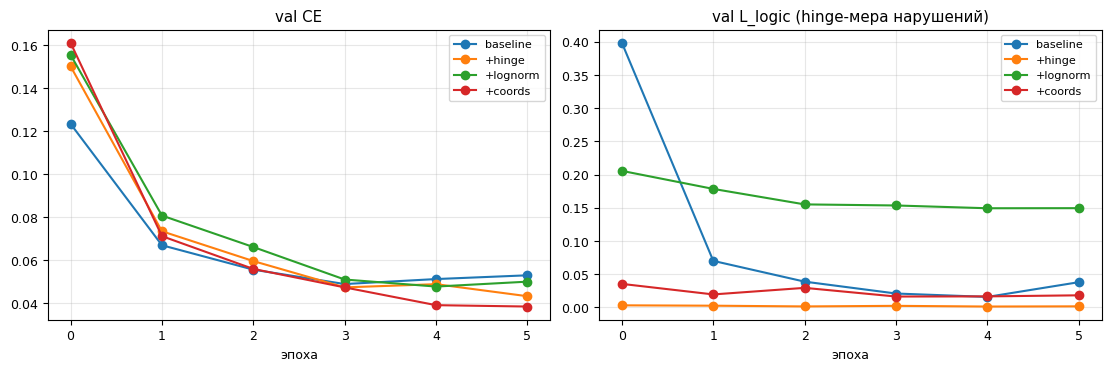

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)
for name, (net, h) in runs.items():
    axes[0].plot(h.ep, h.val_ce, "o-", label=name); axes[1].plot(h.ep, h.val_logic, "o-", label=name)
axes[0].set_title("val CE"); axes[1].set_title("val L_logic (hinge-мера нарушений)")
for ax in axes: ax.set_xlabel("эпоха"); ax.grid(alpha=.3); ax.legend(fontsize=8)
plt.show()

## 9. Оценка: IoU, foF2-ридаут, SHACL-гейт

In [15]:
def evaluate(net, n_gate=24):
    net.eval()
    with torch.no_grad(): lg = net(torch.tensor(X[va_i]))
    pred = lg.argmax(1).numpy(); yv = Y[va_i]
    ious = {}
    for ci, cls in enumerate(CLASSES[1:], 1):
        inter = ((pred == ci) & (yv == ci)).sum(); union = ((pred == ci) | (yv == ci)).sum()
        ious[cls] = inter / union if union else np.nan
    # foF2-ридаут: последняя частота столбца с F2-классом
    fo_pred, fo_true = [], []
    for k, i in enumerate(va_i):
        cols = np.where((pred[k] == 1).sum(0) > 0)[0]
        if len(cols) and np.isfinite(meta.foF2[i]):
            fo_pred.append(f_axis[cols[-1]]); fo_true.append(meta.foF2[i])
    fo_rmse = float(np.sqrt(np.mean((np.array(fo_pred) - np.array(fo_true))**2))) if fo_pred else np.nan
    # SHACL-гейт на подвыборке
    bad = sum(not shacl_gate(pred[k])[0] for k in range(min(n_gate, len(va_i))))
    return ious, fo_rmse, bad / min(n_gate, len(va_i))

rows = []
for name, (net, h) in runs.items():
    ious, fo_rmse, viol = evaluate(net)
    rows.append(dict(run=name, **{f"IoU_{k}": round(v, 3) if np.isfinite(v) else None for k, v in ious.items()},
                     foF2_RMSE=round(fo_rmse, 2) if np.isfinite(fo_rmse) else None,
                     SHACL_нарушений=f"{viol:.0%}"))
res = pd.DataFrame(rows).set_index("run")
display(res)
print("ARTIST-маски через тот же гейт:",
      f"{sum(not shacl_gate(Y[va_i[k]])[0] for k in range(24))/24:.0%} нарушений (санити-чек учителя)")

,IoU_F2,IoU_F1,IoU_E,IoU_Es,foF2_RMSE,SHACL_нарушений
run,,,,,,
baseline,0.192,0.0,0.028,0.013,1.91,0%
+hinge,0.280,0.0,0.092,0.021,0.28,0%
+lognorm,0.333,0.0,0.036,0.010,0.26,0%
+coords,0.340,0.0,0.102,0.034,0.86,0%


ARTIST-маски через тот же гейт: 0% нарушений (санити-чек учителя)


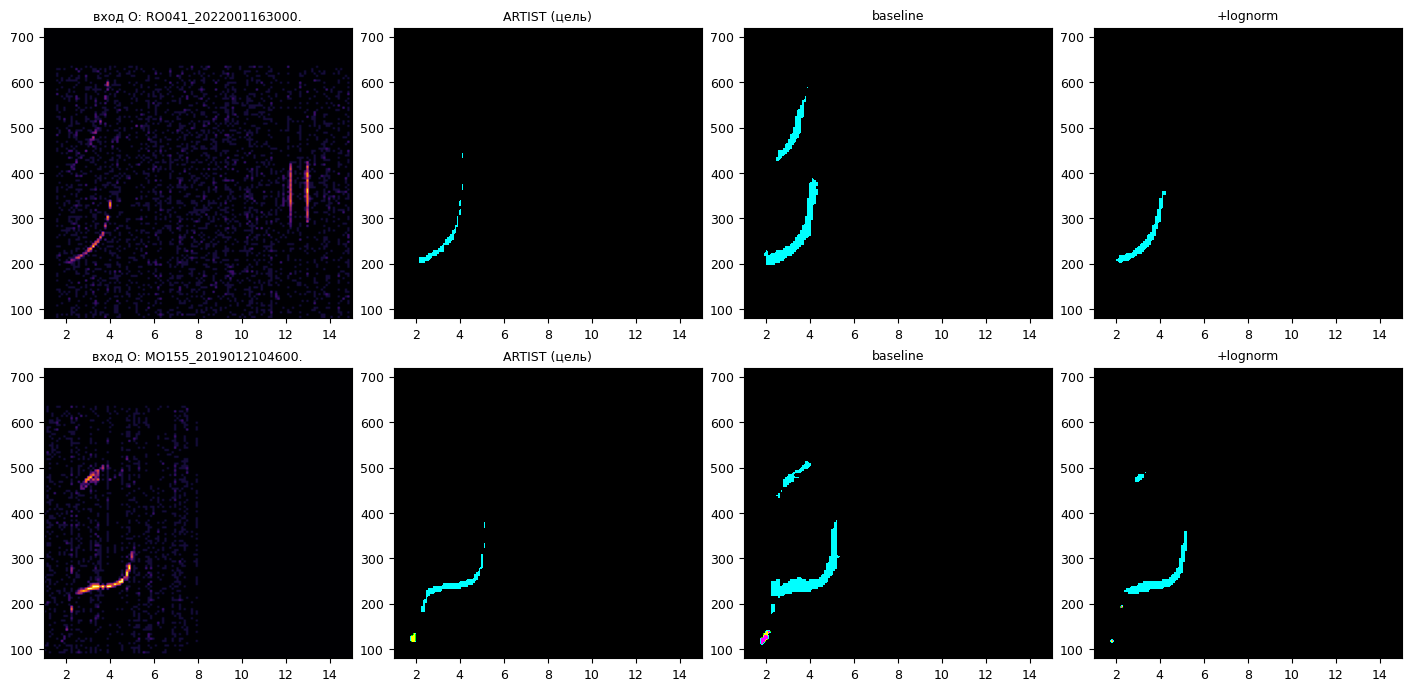

In [16]:
# качественно: вход | ARTIST | baseline | +lognorm на двух примерах валидации
ex = [va_i[0], va_i[len(va_i)//2]]
fig, axes = plt.subplots(len(ex), 4, figsize=(14, 3.4*len(ex)), constrained_layout=True)
for r, i in enumerate(ex):
    with torch.no_grad():
        pb = runs["baseline"][0](torch.tensor(X[i:i+1])).argmax(1)[0].numpy()
        pl = runs["+lognorm"][0](torch.tensor(X[i:i+1])).argmax(1)[0].numpy()
    for c, (img, ttl, cm, vmax) in enumerate([(X[i, 0], f"вход O: {meta.stem[i][:20]}", "inferno", 1),
                                              (Y[i], "ARTIST (цель)", cm_y, 4),
                                              (pb, "baseline", cm_y, 4), (pl, "+lognorm", cm_y, 4)]):
        axes[r, c].imshow(img, origin="lower", cmap=cm, aspect="auto",
                          extent=[F_MIN, F_MAX, H_MIN, H_MAX], vmin=0, vmax=vmax)
        axes[r, c].set_title(ttl, fontsize=9)
plt.show()

## 10. Что показал прототип и что дальше

**Показано на работающем коде:**
1. конвейер RSF → каноническая матрица → маски из SAO → U-Net → предсказание — целиком;
2. онтология НЗ **переносится** на ВЗ (ядро — инвариант; S2/S4/S5 дословно, S1 вырожденно,
   S3/S6 вакуумно) и расширяется декларативно (V3/V4 — новый TTL без правки кода);
3. логическая голова дифференцируема, оба варианта релаксации обучаются; SHACL-гейт
   считает физическую допустимость предсказаний той же онтологией, что и допустимость
   разметки ARTIST (санити-чек учителя — в той же таблице).

**Ограничения прототипа (честно):** выборка мала и почти вся — одна станция/сутки; классы
F1/E/Es представлены слабо (ночные ионограммы); метрики ни о чём не говорят, кроме
работоспособности конвейера; сцена SHACL-гейта содержит только 1-кратные моды (кратники сеть
пока не размечает — их нет и в SAO). Разрыв «модель↔ARTIST» ≠ «модель↔истина»: для второго
нужен внешний тест (Sodankylä-2021 на Zenodo) и своя ручная подвыборка.

**Следующие шаги:** P1-корпус (5 станций × 3 эпохи цикла) → MAE-предобучение на неразмеченном
архиве → v3-декодер со слотами-мод (кортеж признаков вместо классов, стыкуется с ризонером
напрямую) → фильтрация учителя SHACL-ом → эксперимент «выравнивает ли символьный сигнал»
с внешним тестом. См. `data/format_description.md` §I.8.